<a href="https://colab.research.google.com/github/MeghanaGS26/credit-risk-modeling/blob/main/credit_risk_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [23]:
df = pd.read_csv("cs-training.csv", index_col=0)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [24]:
df.info()
print(df.isnull().sum())
print(df["SeriousDlqin2yrs"].value_counts(normalize=True) * 100)
df.describe().T

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [25]:
# Remove impossible ages
df = df[df["age"] > 0].copy()

# 96 and 98 are placeholder codes, not real counts, so treat them as missing
late_cols = ["NumberOfTime30-59DaysPastDueNotWorse",
             "NumberOfTimes90DaysLate",
             "NumberOfTime60-89DaysPastDueNotWorse"]
for c in late_cols:
    df[c] = df[c].replace([96, 98], np.nan)

print(df.shape)
print(df.isnull().sum())

(149999, 11)
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse      269
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   269
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse      269
NumberOfDependents                       3924
dtype: int64


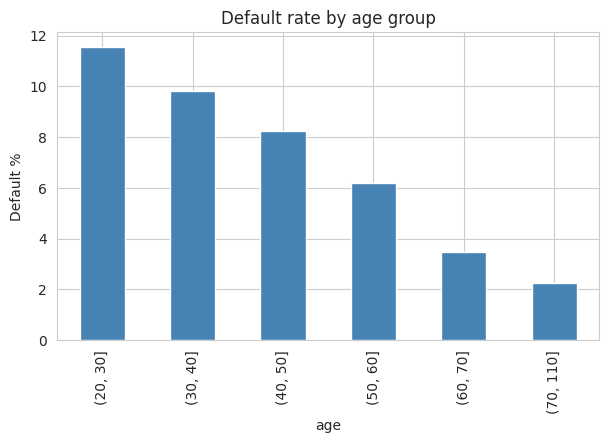

In [26]:
target = "SeriousDlqin2yrs"

age_bins = pd.cut(df["age"], bins=[20, 30, 40, 50, 60, 70, 110])
rate = df.groupby(age_bins, observed=True)[target].mean() * 100

rate.plot(kind="bar", color="steelblue", figsize=(7, 4))
plt.title("Default rate by age group")
plt.ylabel("Default %")
plt.show()

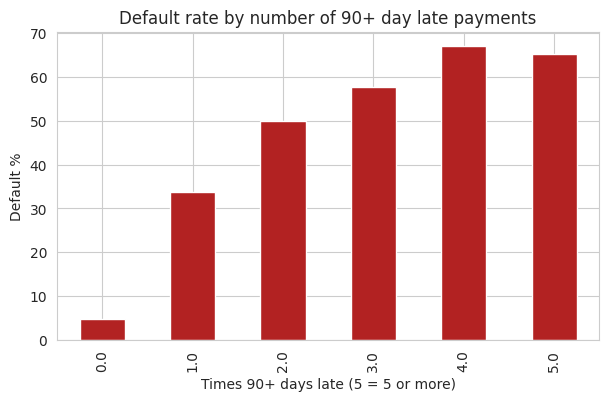

In [27]:
late = df["NumberOfTimes90DaysLate"].clip(upper=5)
(df.groupby(late)[target].mean() * 100).plot(kind="bar", color="firebrick", figsize=(7, 4))
plt.title("Default rate by number of 90+ day late payments")
plt.xlabel("Times 90+ days late (5 = 5 or more)")
plt.ylabel("Default %")
plt.show()

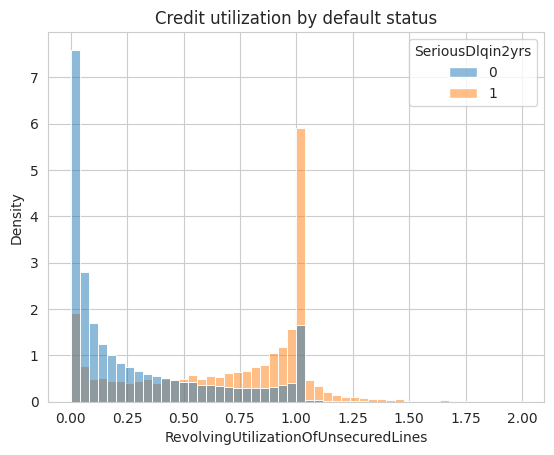

In [28]:
sub = df[df["RevolvingUtilizationOfUnsecuredLines"] <= 2]
sns.histplot(data=sub, x="RevolvingUtilizationOfUnsecuredLines",
             hue=target, bins=50, stat="density", common_norm=False)
plt.title("Credit utilization by default status")
plt.show()

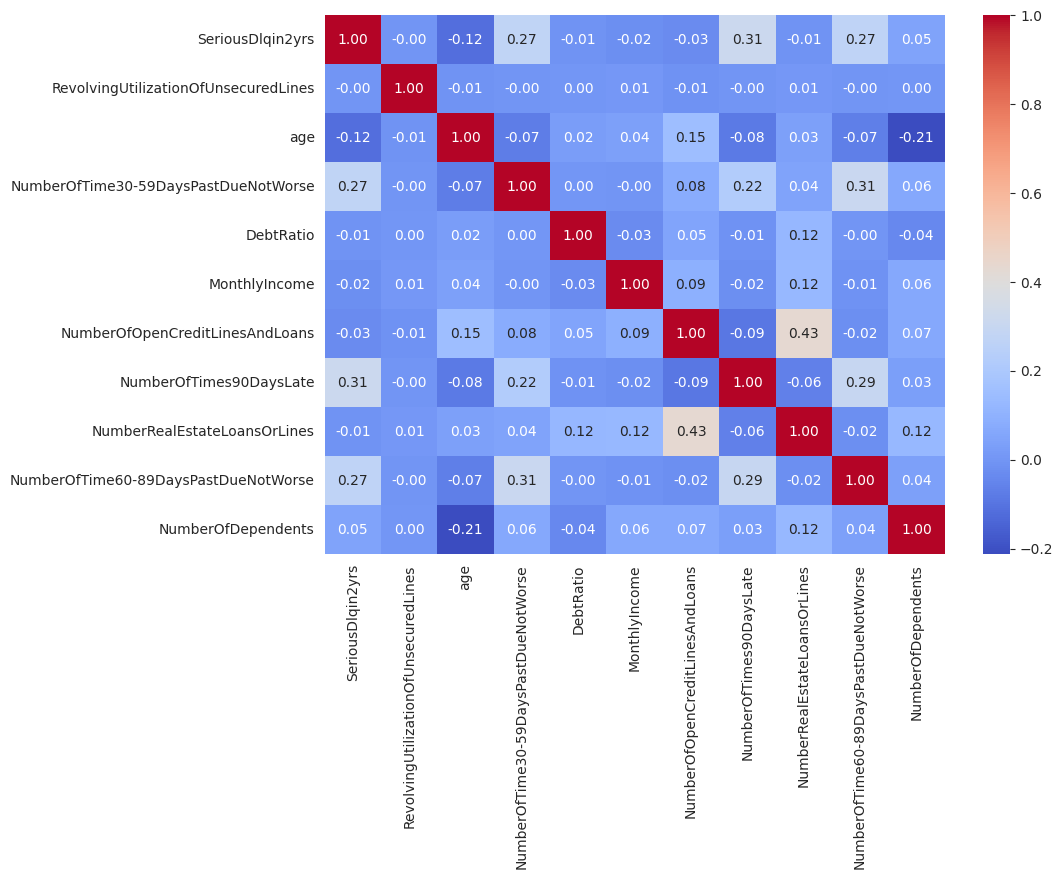

In [29]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(119999, 10) (30000, 10)
0.06684222368519738 0.06683333333333333


In [31]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

print(X_train.isnull().sum().sum(), "missing values left")

0 missing values left


In [32]:
cap_cols = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]
for c in cap_cols:
    cap = X_train[c].quantile(0.99)
    X_train[c] = X_train[c].clip(upper=cap)
    X_test[c] = X_test[c].clip(upper=cap)

X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,119999.0,0.320132,0.352162,0.0,0.029663,0.153211,0.558129,1.095907
age,119999.0,52.315044,14.758696,21.0,41.000000,52.000000,63.000000,109.000000
NumberOfTime30-59DaysPastDueNotWorse,119999.0,0.245202,0.696959,0.0,0.000000,0.000000,0.000000,13.000000
DebtRatio,119999.0,316.919963,908.002855,0.0,0.175373,0.366829,0.864803,4983.040000
MonthlyIncome,119999.0,6144.793498,3836.542599,0.0,3900.000000,5400.000000,7400.000000,23018.300000
NumberOfOpenCreditLinesAndLoans,119999.0,8.463721,5.152946,0.0,5.000000,8.000000,11.000000,58.000000
NumberOfTimes90DaysLate,119999.0,0.090017,0.482563,0.0,0.000000,0.000000,0.000000,17.000000
NumberRealEstateLoansOrLines,119999.0,1.019617,1.135512,0.0,0.000000,1.000000,2.000000,54.000000
NumberOfTime60-89DaysPastDueNotWorse,119999.0,0.065184,0.330963,0.0,0.000000,0.000000,0.000000,11.000000
NumberOfDependents,119999.0,0.736198,1.107638,0.0,0.000000,0.000000,1.000000,20.000000


In [33]:
print(X_train.shape, X_test.shape)
print("Default rate train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))

(119999, 10) (30000, 10)
Default rate train: 0.0668 | test: 0.0668


In [34]:
# If this import fails, run: !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_train_sm).value_counts())

Before SMOTE:
 SeriousDlqin2yrs
0    111978
1      8021
Name: count, dtype: int64
After SMOTE:
 SeriousDlqin2yrs
0    111978
1    111978
Name: count, dtype: int64


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=12, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                             eval_metric="logloss", random_state=42),
}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    print(name, "trained")

Logistic Regression trained
Decision Tree trained
Random Forest trained
XGBoost trained


In [36]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

results = []
for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.818,0.230,0.737,0.351,0.861
Decision Tree,0.922,0.400,0.324,0.358,0.825
Random Forest,0.927,0.441,0.353,0.392,0.860
XGBoost,0.934,0.523,0.222,0.312,0.862


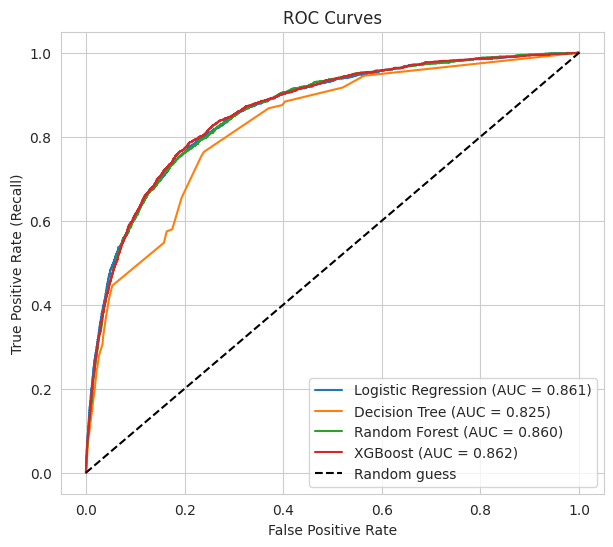

Best model: XGBoost


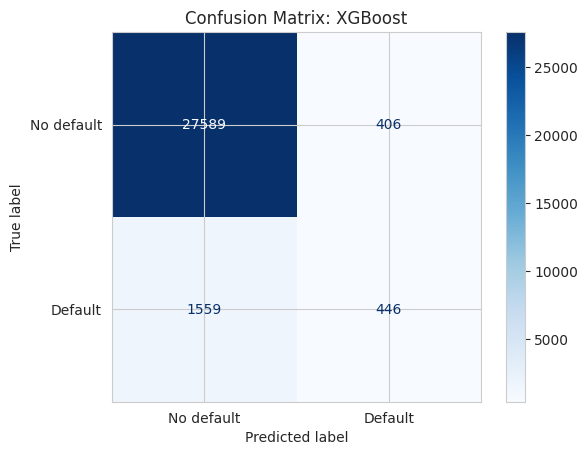

In [37]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves")
plt.legend()
plt.show()

best_name = results_df["ROC-AUC"].idxmax()
print("Best model:", best_name)
ConfusionMatrixDisplay.from_estimator(models[best_name], X_test, y_test,
                                      display_labels=["No default", "Default"], cmap="Blues")
plt.title(f"Confusion Matrix: {best_name}")
plt.show()

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = models["XGBoost"].predict_proba(X_test)[:, 1]

rows = []
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
    pred = (proba >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })

pd.DataFrame(rows).round(3)

,Threshold,Precision,Recall,F1
0,0.1,0.208,0.789,0.329
1,0.2,0.329,0.580,0.420
2,0.3,0.407,0.439,0.422
3,0.4,0.467,0.328,0.386
4,0.5,0.523,0.222,0.312
5,0.6,0.559,0.132,0.213


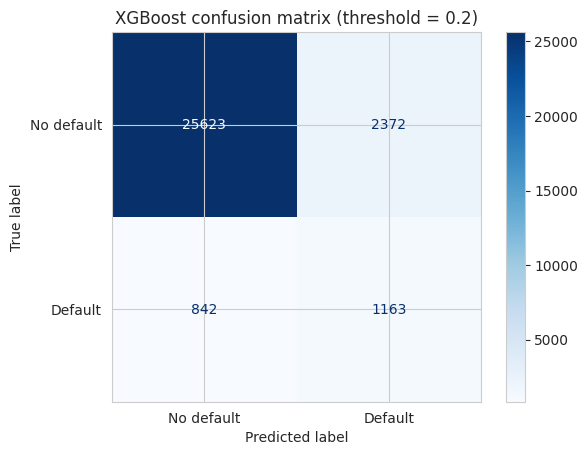

Recall: 0.58
Precision: 0.329


In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score

threshold = 0.2
proba = models["XGBoost"].predict_proba(X_test)[:, 1]
pred_tuned = (proba >= threshold).astype(int)

cm = confusion_matrix(y_test, pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(cmap="Blues")
plt.title("XGBoost confusion matrix (threshold = 0.2)")
plt.show()

print("Recall:", round(recall_score(y_test, pred_tuned), 3))
print("Precision:", round(precision_score(y_test, pred_tuned), 3))

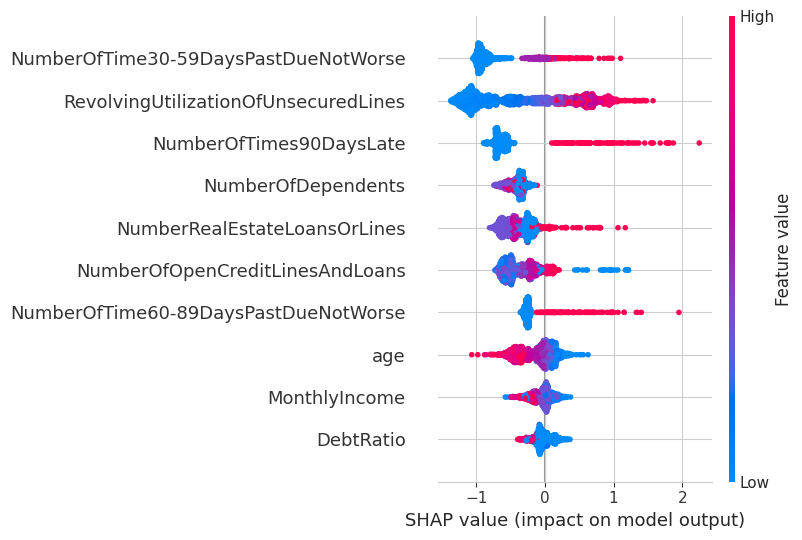

In [40]:
import shap

explainer = shap.TreeExplainer(models["XGBoost"])
sample = X_test.sample(2000, random_state=42)   # a sample keeps it fast
shap_values = explainer.shap_values(sample)

# Global view: which features matter most, and in which direction
shap.summary_plot(shap_values, sample)

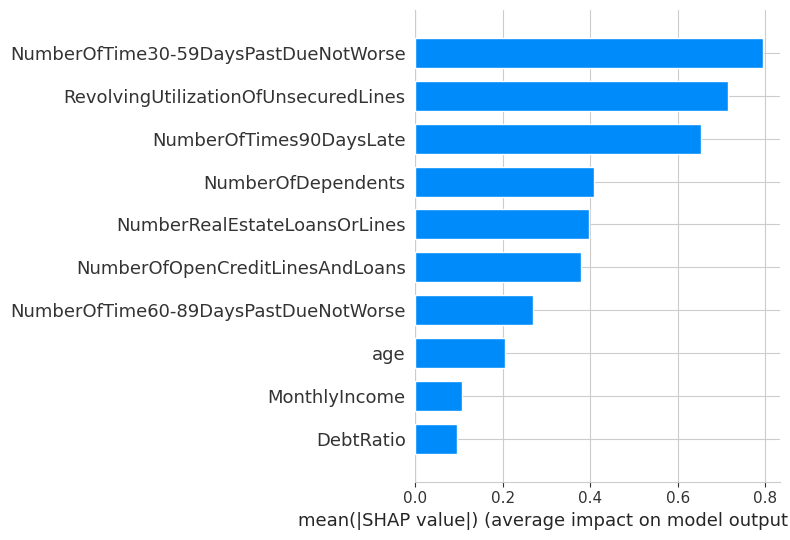

In [41]:
# Simple bar version of overall importance
shap.summary_plot(shap_values, sample, plot_type="bar")

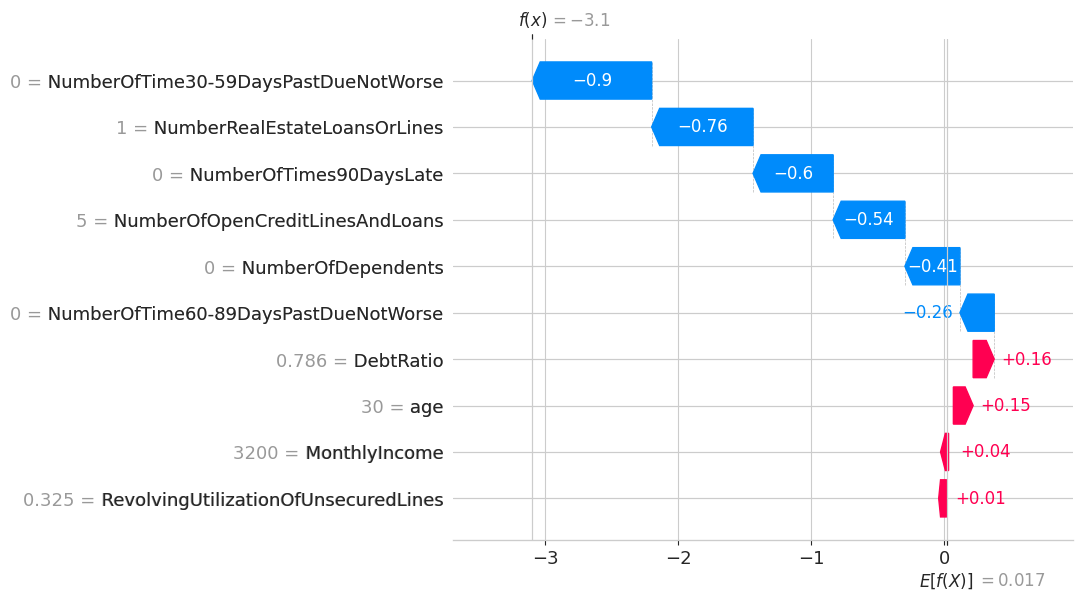

In [42]:
# One individual prediction explained
sv = explainer(sample)
shap.plots.waterfall(sv[0])

## Key Findings
- Payment history is the strongest signal of default: borrowers with more 30-59 day, 60-89 day and 90+ day late payments have a much higher predicted risk.
- High credit utilization (using most of the available credit limit) pushes risk up.
- Older borrowers show lower default risk than younger ones, and higher income lowers risk slightly.
- Only 6.7% of borrowers defaulted, so accuracy is misleading (a model that predicts "no default" for everyone scores about 93%). Recall, precision and ROC-AUC were used instead.

## Model Results
- ROC-AUC on the test set: XGBoost 0.862, Logistic Regression 0.861, Random Forest 0.860, Decision Tree 0.825.
- At the default threshold of 0.5, XGBoost caught only 22% of defaulters (recall 0.222).
- Lowering the threshold to 0.2 raised recall to 0.58 (1,163 of 2,005 defaulters caught), with precision of 0.329.

## Business Recommendations
1. Prioritize payment history and credit utilization in loan screening.
2. Use a lower decision threshold (0.2) when missing a defaulter costs more than reviewing an extra applicant, and send flagged applicants to manual review rather than automatic rejection.
3. Use SHAP explanations to give reasons for each decision, which supports fair and transparent lending.
4. Monitor the model over time, because borrower behavior changes.
